In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [27]:
# 加载Iris数据集
iris = load_iris()
X, y = iris.data[:, :2], iris.target

In [28]:
# 将数据集拆分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(105, 2) (105,) (45, 2) (45,)


In [29]:
# 创建KNN模型，设置K值为3
knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')

In [30]:
# 训练模型
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'euclidean'
,metric_params,None
,n_jobs,None


In [31]:
# 在测试集上进行预测
y_pred = knn.predict(X_test)

In [32]:
# 计算准确率
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy:.4f}")

Model accuracy: 0.7556


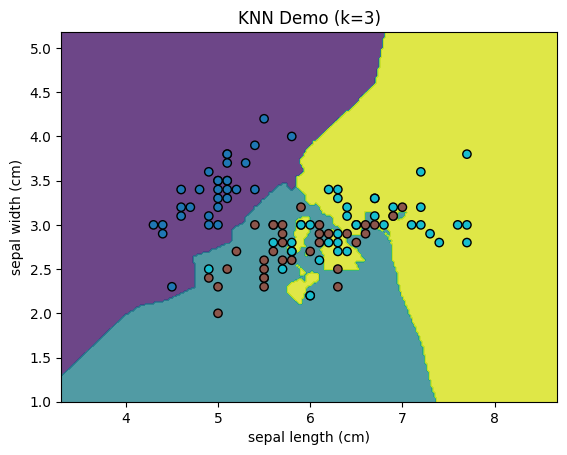

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# 绘制决策边界和数据点
h = .02# 网格步长
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1

# 创建一个二维网格，表示不同的样本空间
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# 使用KNN模型预测网格中的每个点的类别
Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 绘制决策边界
plt.contourf(xx, yy, Z, alpha=0.8, cmap='viridis')

# 绘制训练数据点
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='tab10', edgecolor='k')
plt.title(f'KNN Demo (k={knn.n_neighbors})')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()